In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

In [35]:
temps = np.arange(0.5,2.1,0.1)

points=100
T = np.linspace(0.2,2.3,num=points)
b = 1/T
J = 1.0
h = 0.02
Ns = 50
th = np.tanh(J/T)
thN= th**Ns
ch = 1/th
e = -J*( th + ch*thN )/( 1 + thN )
heat=((b*J)**2)*(((1+thN+(Ns-1)*(th**2)+(Ns-1)*(ch**2)*thN)/(1+thN))-Ns*((th+ch*thN)/(1+thN))**2)
l1 = np.exp(b*J)*np.cosh(b*h)+np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
l2 = np.exp(b*J)*np.cosh(b*h)-np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
Z = l1**Ns + l2**Ns
M = (np.exp(b*J)*np.sinh(b*h)*((l1**(Ns-1))*(1+np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))) 
        + (l2**(Ns-1))*(1-np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J)))))/(Z)
X = b*np.exp(2*b*J)*(1-thN)/(1+thN)


total_energy_metr = np.array([np.loadtxt(f"../OUTPUT-METROPOLIS/total_energy_{temp:.1f}.dat", usecols=(2,3))[-1] for temp in temps])
total_energy_gibbs = np.array([np.loadtxt(f"../OUTPUT-GIBBS/total_energy_{temp:.1f}.dat", usecols=(2,3))[-1] for temp in temps])

cv_metr = np.array([np.loadtxt(f"../OUTPUT-METROPOLIS/specific_heat_{temp:.1f}.dat", usecols=(2,3))[-1] for temp in temps])
cv_gibbs = np.array([np.loadtxt(f"../OUTPUT-GIBBS/specific_heat_{temp:.1f}.dat", usecols=(2,3))[-1] for temp in temps])

chi_metr = np.array([np.loadtxt(f"../OUTPUT-METROPOLIS/susceptibility_{temp:.1f}.dat", usecols=(2,3))[-1] for temp in temps])
chi_gibbs = np.array([np.loadtxt(f"../OUTPUT-GIBBS/susceptibility_{temp:.1f}.dat", usecols=(2,3))[-1] for temp in temps])

magnet_metr = np.array([np.loadtxt(f"../OUTPUT-METROPOLIS/magnetization_{temp:.1f}.dat", usecols=(2,3))[-1] for temp in temps])
magnet_gibbs = np.array([np.loadtxt(f"../OUTPUT-GIBBS/magnetization_{temp:.1f}.dat", usecols=(2,3))[-1] for temp in temps])

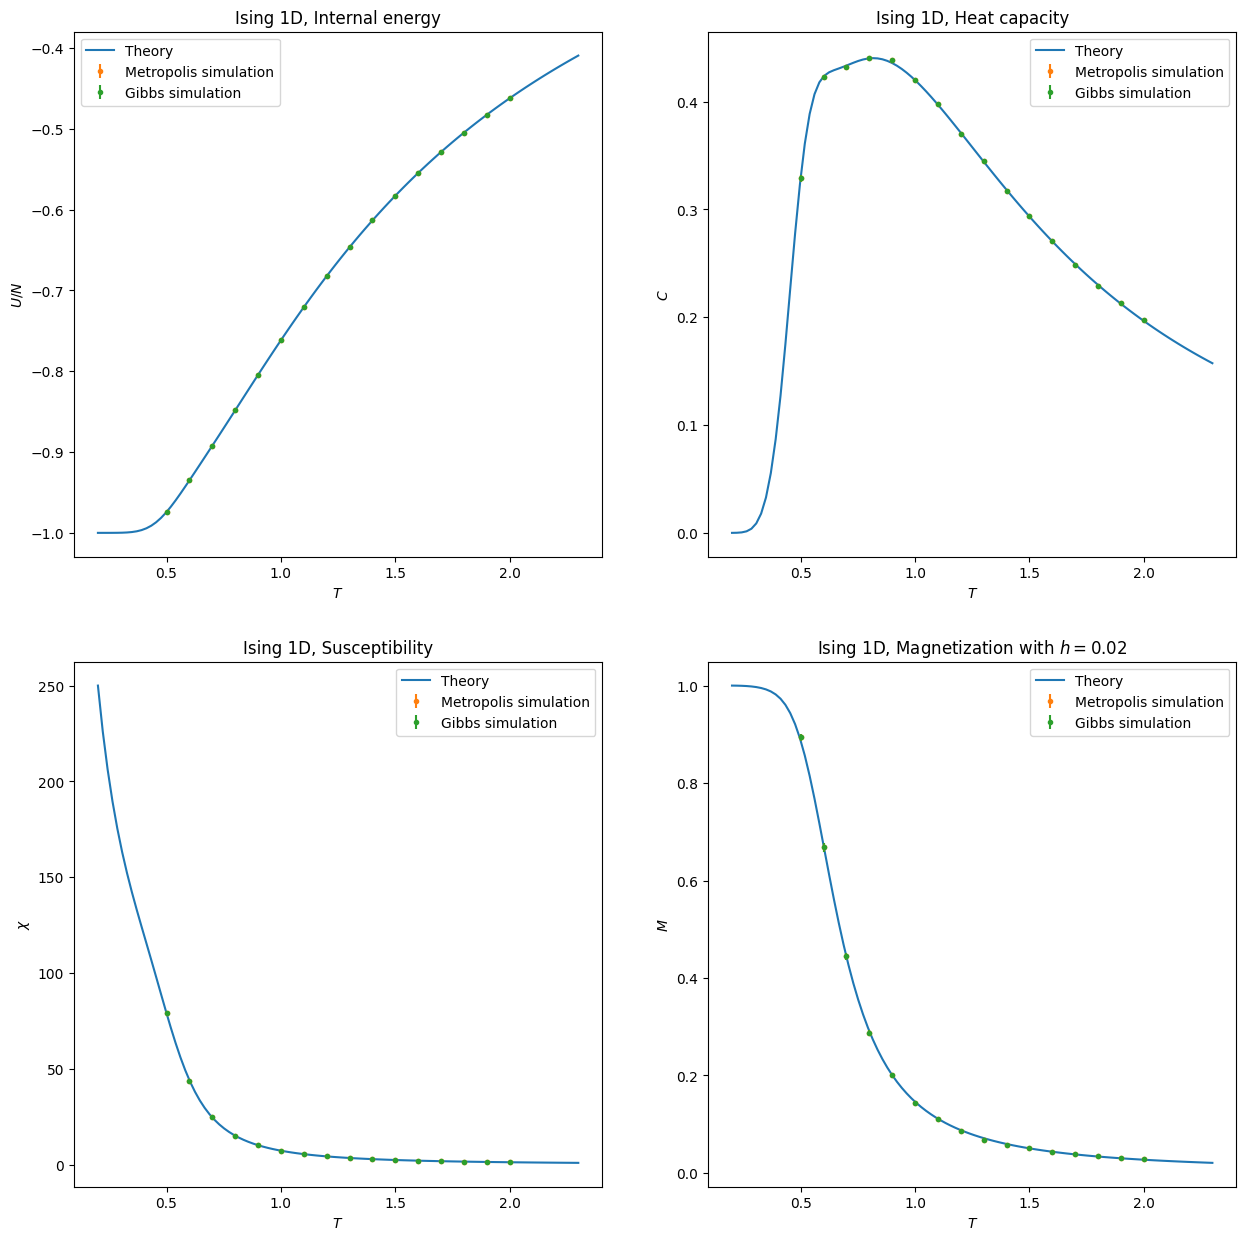

In [36]:
fig, ax = plt.subplots(2, 2, figsize=(15,15))
ax = ax.flatten()

theory = [e, heat, X, M]
metropolis = [total_energy_metr, cv_metr, chi_metr, magnet_metr]
gibbs = [total_energy_gibbs, cv_gibbs, chi_gibbs, magnet_gibbs]
ylabels = ["$U/N$", "$C$", "$\chi$", "$M$"]
titles = ["Ising 1D, Internal energy", "Ising 1D, Heat capacity", "Ising 1D, Susceptibility", "Ising 1D, Magnetization with $h = 0.02$"]
# Internal energy
for i in range(4):
    ax[i].plot(T, theory[i], label="Theory")
    ax[i].errorbar(temps, metropolis[i][:,0], yerr=metropolis[i][:,1], fmt=".", label="Metropolis simulation")
    ax[i].errorbar(temps, gibbs[i][:,0], yerr=gibbs[i][:,1], fmt=".", label="Gibbs simulation")

    ax[i].set_title(titles[i])
    ax[i].set_xlabel('$T$')
    ax[i].set_ylabel(ylabels[i])
    ax[i].legend();
